# TP d'analyse numérique – Modélisation d'une bouteille à partir d'un profil donné a l'aide des spline cubiques 
Ce TP nous a été proposé dans le cadre du cours d'analyse numérique dispensé par le Pr Abdou Njifendjou en 3e annee du cycle d'ingenieur à l'Ecole Nationale Superieure Polytechnique de Douala comme devoir d'application directe de l'interpolation par les splines cubiques a rendre.(https://www.researchgate.net/profile/Abdou-Njifenjou/publication/353447793_Polynomial_Interpolation_and_Numerical_Integration_A_short_Introduction/links/60fdf9bb0c2bfa282aff2320/Polynomial-Interpolation-and-Numerical-Integration-A-short-Introduction.pdf)



## 1. Formulation du problème

On dispose d’un ensemble de points mesurés représentant le profil d’un objet :

$$
(x_0,y_0),(x_1,y_1),\dots,(x_n,y_n)
$$

où :

- $x_i$ représente la position le long de l’axe
- $y_i$ représente la valeur mesurée (par exemple le rayon du profil d’une bouteille)

On suppose que les abscisses sont **uniformément espacées** :

$$
h = x_{i+1}-x_i
$$

L’objectif est de construire une fonction $S(x)$ qui :

1. interpole les données

$$
S(x_i)=y_i
$$

2. soit **lisse** sur tout l’intervalle $[x_0,x_n]$

---

# 2. Approximation par polynômes par morceaux

On divise l’intervalle en sous-intervalles avec un pas uniforme:

$$
[x_0,x_1], [x_1,x_2], \dots, [x_{n-1},x_n]
$$

Sur chaque intervalle on définit un polynôme cubique :

$$
S_i(x)=a_i+b_i(x-x_i)+c_i(x-x_i)^2+d_i(x-x_i)^3
$$

pour

$$
x\in[x_i,x_{i+1}]
$$

Pourquoi un **polynôme cubique** ?

- degré 1 : pas assez flexible
- degré 2 : continuité de courbure impossible
- degré 3 : premier degré permettant continuité de courbure

---

# 3. Conditions d'interpolation

La courbe doit passer par les points mesurés.

### Condition 1

$$
S_i(x_i)=y_i
$$

Donc

$$
a_i=y_i
$$

---

### Condition 2

$$
S_i(x_{i+1})=y_{i+1}
$$

Or

$$
x_{i+1}-x_i=h
$$

Donc

$$
y_{i+1}=y_i+b_i h+c_i h^2+d_i h^3
$$

---

# 4. Continuité entre les segments de profil

La spline doit être **lisse**; Cela impose trois conditions géométriques. Plusieurs conditions par rapport a nos splines:

---

## 4.1 Continuité de la fonction

Au point $x_i$ :

$$
S_{i-1}(x_i)=S_i(x_i)
$$

**Interprétation géométrique**

Ce qui traduit le fait que les segments doivent **se rejoindre sans discontinuité**.

---

## 4.2 Continuité de la pente

On impose :

$$
S'_{i-1}(x_i)=S'_i(x_i)
$$

Ce qui traduit que la tangente a la courbe doit être la même des deux côtés de $$x_i$$

Sinon on aurait un **angle pointu**.

---

## 4.3 Continuité de la courbure

On impose :

$$
S''_{i-1}(x_i)=S''_i(x_i)
$$


Traduisant que la courbe doit se plier de manière régulière. Sinon la courbure changerait brutalement.

---

# 5. Introduction des paramètres $\alpha_i$

On définit

$$
\alpha_i = S''(x_i)
$$

Ces quantités représentent :

**la courbure de la spline aux points d’échantillonnage**.

---

# 6. Calcul des dérivées

### Dérivée

$$
S'_i(x)=b_i+2c_i(x-x_i)+3d_i(x-x_i)^2
$$

---

### Dérivée seconde

$$
S''_i(x)=2c_i+6d_i(x-x_i)
$$

---

# 7. Relation entre coefficients et $\alpha$

Au point $x_i$

$$
S''_i(x_i)=2c_i
$$

donc

$$
c_i=\frac{\alpha_i}{2}
$$

---

Au point $x_{i+1}$

$$
S''_i(x_{i+1})=2c_i+6d_i h
$$

mais

$$
S''_i(x_{i+1})=\alpha_{i+1}
$$

donc

$$
\alpha_{i+1}= \alpha_i+6d_i h
$$

d'où

$$
d_i=\frac{\alpha_{i+1}-\alpha_i}{6h}
$$

---

# 8. Calcul de $b_i$

On repart de

$$
y_{i+1}=y_i+b_i h+c_i h^2+d_i h^3
$$

Substitution :

$$
c_i=\frac{\alpha_i}{2}
$$

$$
d_i=\frac{\alpha_{i+1}-\alpha_i}{6h}
$$

donne

$$
y_{i+1}-y_i=b_i h+\frac{\alpha_i}{2}h^2+\frac{\alpha_{i+1}-\alpha_i}{6}h^2
$$

Simplification :

$$
y_{i+1}-y_i=b_i h+\frac{h^2}{6}(2\alpha_i+\alpha_{i+1})
$$

donc

$$
b_i=\frac{y_{i+1}-y_i}{h}-\frac{h}{6}(2\alpha_i+\alpha_{i+1})
$$

---

# 9. Expression finale de la spline

Après substitution des coefficients obtenu precedement, on obtien l'expression finale suivante :

$$
S_i(x)=
\frac{\alpha_i}{6h}(x_{i+1}-x)^3
+
\frac{\alpha_{i+1}}{6h}(x-x_i)^3
+
\left(\frac{y_i}{h}-\frac{\alpha_i h}{6}\right)(x_{i+1}-x)
+
\left(\frac{y_{i+1}}{h}-\frac{\alpha_{i+1} h}{6}\right)(x-x_i)
$$

Cette expression montre que la spline dépend uniquement des :

$$
\alpha_i
$$
Determiner l'expresion finale des spline revient donc a determiner les $$\alpha_i$$
---

# 10. Détermination des $\alpha_i$

Pour trouver les $\alpha_i$, on utilise la **continuité de la dérivée**.

Condition :

$$
S'_i(x_{i+1}) = S'_{i+1}(x_{i+1})
$$

Après substitution des expressions de $b_i$ on obtient :

$$
\alpha_{i-1}+4\alpha_i+\alpha_{i+1}
=
\frac{6}{h^2}(y_{i+1}-2y_i+y_{i-1})
$$

pour

$$
i=1,\dots,n-1
$$

---

# 11. Conditions aux bords (spline naturelle)

On impose :

$$
\alpha_0=0
$$

$$
\alpha_n=0
$$

**Interprétation géométrique**

Les extrémités sont **sans contrainte de courbure**.

La spline se comporte comme une **règle flexible posée sur les points**.

---

# 12. Système matriciel a resoudre 

On obtient le système linéaire sous forme matricielle:

$$
A\alpha = b
$$

avec

$$
\alpha =
\begin{bmatrix}
\alpha_0 \\
\alpha_1 \\
\vdots \\
\alpha_n
\end{bmatrix}
$$

---

## Matrice

$$
A=
\begin{bmatrix}
1 & 0 & 0 & 0 & \dots & 0 \\
1 & 4 & 1 & 0 & \dots & 0 \\
0 & 1 & 4 & 1 & \dots & 0 \\
0 & 0 & 1 & 4 & 1 & 0 \\
\vdots & & & & & \vdots \\
0 & \dots & 0 & 1 & 4 & 1 \\
0 & \dots & 0 & 0 & 0 & 1
\end{bmatrix}
$$

---

## Second membre

$$
b=
\begin{bmatrix}
0 \\
\frac{6}{h^2}(y_2-2y_1+y_0) \\
\frac{6}{h^2}(y_3-2y_2+y_1) \\
\vdots \\
\frac{6}{h^2}(y_n-2y_{n-1}+y_{n-2}) \\
0
\end{bmatrix}
$$

---

# 13. Conclusion

La construction de la spline cubique se fait en trois étapes :

1. résolution du système pour obtenir les $\alpha_i$
2. reconstruction de $S_i(x)$ sur chaque intervalle
3. utilisation de $S(x)$ pour les calculs (volume, dérivées, etc.)

La matrice obtenue est **tridiagonale**, ce qui permet une résolution très efficace.

Nous mettrons donc en oeuvre chacunes des etapes citees ci dessus a l'aide de Python et Numpy

le code ci dessous est disponible sur https://github.com/Sirpg/Ma-bouteille

In [49]:

import numpy as np
import matplotlib.pyplot as plt


In [50]:

y = [
3.30, 3.31, 3.32, 3.34, 3.36, 3.39, 3.42, 3.45, 3.49, 3.53,
3.57, 3.62, 3.66, 3.71, 3.75, 3.79, 3.83, 3.87, 3.90, 3.93,
3.96, 3.99, 4.01, 4.03, 4.05, 4.06, 4.07, 4.08, 4.09, 4.09,
4.09, 4.08, 4.07, 4.06, 4.05, 4.03, 4.01, 3.99, 3.97, 3.95,
3.93, 3.91, 3.89, 3.87, 3.85, 3.83, 3.81, 3.79, 3.77, 3.75,
3.73, 3.71, 3.69, 3.67, 3.65, 3.63, 3.61, 3.59, 3.57, 3.55,
3.53, 3.51, 3.49, 3.47, 3.45, 3.43, 3.41, 3.39, 3.37, 3.35,
3.33, 3.31, 3.29, 3.27, 3.25, 3.23, 3.21, 3.19, 3.17, 3.15,
3.13, 3.11, 3.09, 3.07, 3.05, 3.03, 3.01, 2.99, 2.97, 2.95,
2.93, 2.91, 2.89, 2.87, 2.85, 2.83, 2.81, 2.79, 2.77, 2.75,
2.73
]
x=np.linspace(0,20,len(y)) 

#Determination des Alphas pour evaluer les splines

def Alpha(x,y):
    h=x[1]-x[0]
    n=len(y)-1
    A=np.zeros((n+1,n+1))
    b=np.zeros(n+1)

    A[0,0]=1
    A[n,n]=1

    #formation de la matrice A telle que AX=b
    for i in range(1,n):
        A[i,i-1] = 1
        A[i,i] = 4
        A[i,i+1] = 1

        b[i] = 6*(y[i+1]-2*y[i]+y[i-1])/(h**2)

    #On obtient donc les derivee secondes suivantes dans X en resolvant le systeme matriciel 
    X=np.linalg.solve(A, b)

    return X

def spline_eval(x, y, X, xp): #evaluation de la spline en xp avec x, y, X contenant les alpha

    h = x[1]-x[0]
    n = len(x)-1

    i = int((xp-x[0])/h)
    if i>=n:
        i=n-1

    xi = x[i]
    xi1 = x[i+1]

    A = (xi1-xp)/h
    B = (xp-xi)/h

    S = (
        A*y[i] + B*y[i+1]
        + ((A**3-A)*X[i] + (B**3-B)*X[i+1])*(h**2)/6
    )

    return S

In [51]:
X=Alpha(x,y)
spline_eval(x,y,X,18.33)

np.float64(2.8970000000000415)

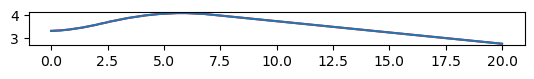

In [56]:
#Tracé du profil de la bouteille interpolé par les splines

M = Alpha(x,y)

xp = np.linspace(0,20,101)
yp = [spline_eval(x,y,M,val) for val in xp]

plt.plot(x,y,'r')
plt.plot(xp,yp)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

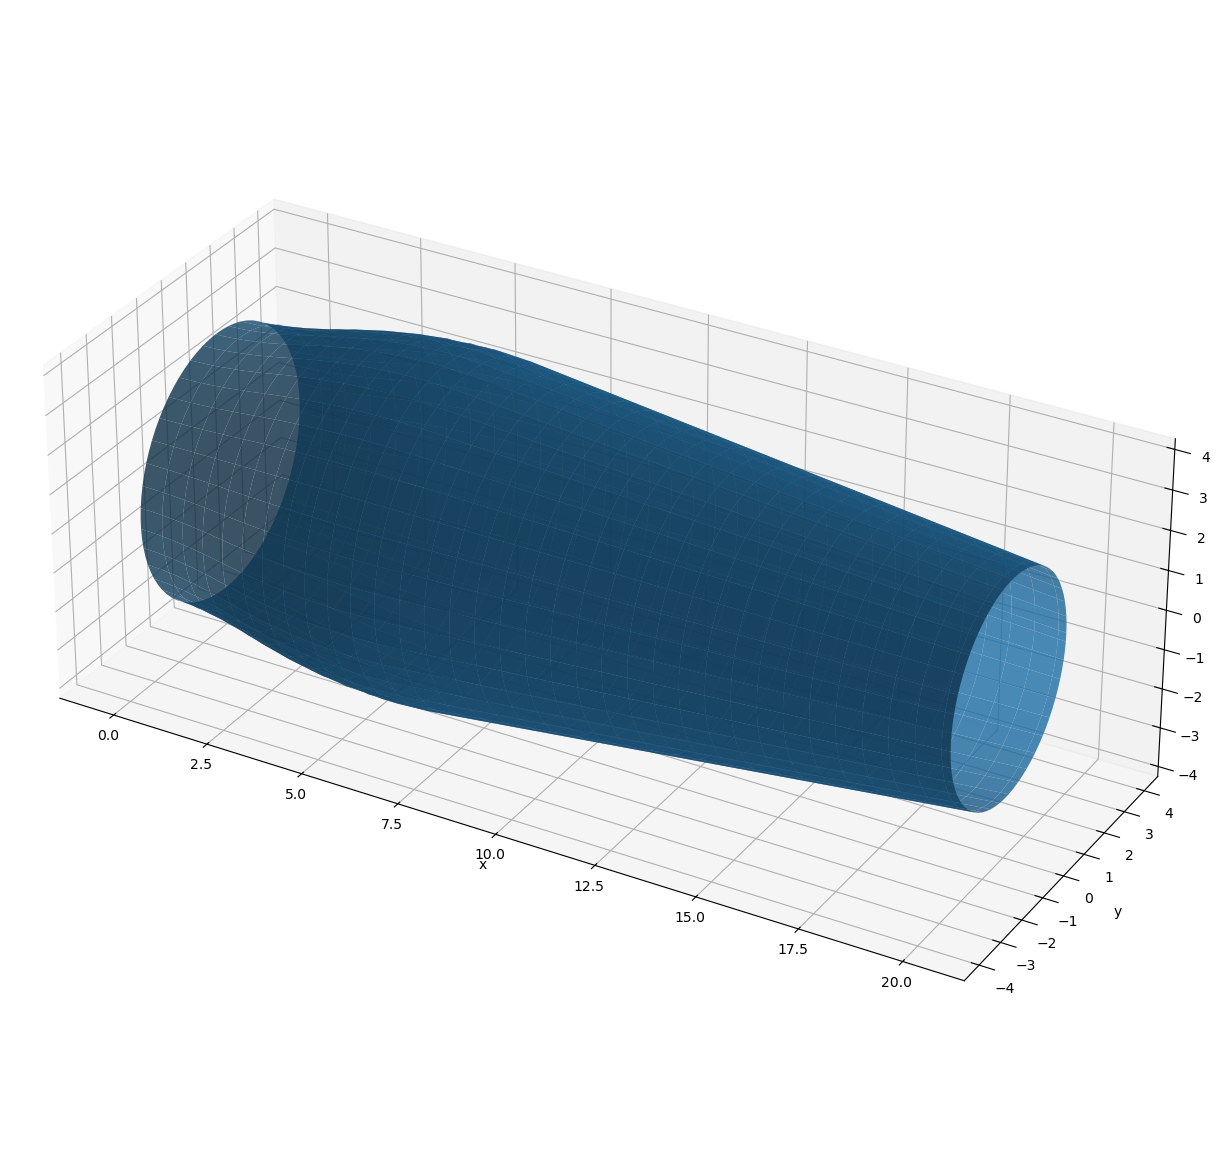

In [59]:
###On se donne maintenant pour tache de representer la bouteille en 3D en faisant
###Roter notre profil autour de l'axe des x
# angle de rotation
theta = np.linspace(0,2*np.pi,80)

# création de la grille
X,Theta = np.meshgrid(xp,theta)

# rayon
R = np.array(yp)

# coordonnées 3D
Y = R*np.cos(Theta)
Z = R*np.sin(Theta)

# répéter X pour la grille
X = np.tile(x,(len(theta),1))

# figure
fig = plt.figure(figsize=(15,15))
ax = fig.add_subplot(projection='3d')

ax.plot_surface(X,Y,Z,alpha=0.8)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
plt.gca().set_aspect('equal', adjustable='box')
plt.show()


C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_6260\760500568.py:27: RuntimeWarning: invalid value encountered in sqrt
  y_cap = np.sqrt(R**2 - (x_cap - xc)**2)


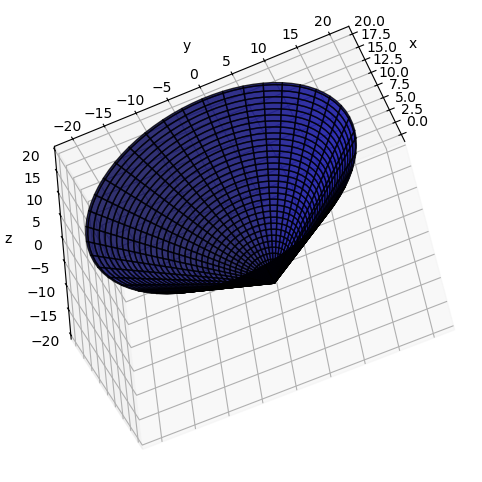

In [58]:
###Dans cette portion on se donne donner un fond a notre bouteille. l'option la plus simple nous a semblee
### d'utiliser une calotte spherique pour le fonct et la stanilite

# ----------------------
# PROFIL DE LA BOUTEILLE
# ----------------------
y_bottle = xp

x_bottle = np.linspace(0, 20, len(y_bottle))

theta = np.linspace(0, 2*np.pi, 80)

X_bottle, Theta_bottle = np.meshgrid(x_bottle, theta)
R_bottle = np.tile(y_bottle, (len(theta),1))
Y_bottle = R_bottle * np.cos(Theta_bottle)
Z_bottle = R_bottle * np.sin(Theta_bottle)


# CALOTTE SPHERIQUE (FOND)

r0 = y_bottle[0]  # rayon du cercle de base qui correspond aussi au cercle de base de la bouteille
depth = 1.5        # profondeur de la calotte(elle se courbe vers l interieur de la bouteille)
xc = depth
R = np.sqrt(r0**2 + depth**2)

x_cap = np.linspace(-depth, 0, 30)
y_cap = np.sqrt(R**2 - (x_cap - xc)**2)

X_cap, Theta_cap = np.meshgrid(x_cap, theta)
R_cap = np.tile(y_cap, (len(theta),1))
Y_cap = R_cap * np.cos(Theta_cap)
Z_cap = R_cap * np.sin(Theta_cap)

# ----------------------
# AFFICHAGE
# ----------------------
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(projection='3d')

# surface de la bouteille
ax.plot_surface(X_bottle, Y_bottle, Z_bottle, alpha=0.8, color='blue', edgecolor='k')

# surface de la calotte
ax.plot_surface(X_cap, Y_cap, Z_cap, alpha=0.8, color='red', edgecolor='k')

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.view_init(-50,15,10)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()